# Reconstructing my thermally induced borehole breakout model in Python
# Kalu's Python FDEM Project

This notebook revisits my 10 m × 10 m Irazu model with an inspectable thermo-mechanical FDEM-style solver. The aim is to expose the mechanics, verify the implementation, and compare the reconstruction with my exported Irazu data. It is not presented as a clone of Irazu.

## 1. Formulation

Heat conduction is solved on shared geometric nodes,

$$\rho c_p\frac{\partial T}{\partial t}-\nabla\cdot(k\nabla T)=0.$$

For mechanics, each constant-strain triangle owns its nodes and neighbouring faces are joined by zero-thickness cohesive elements:

$$\mathbf M\ddot{\mathbf u}=\mathbf f_{bulk}+\mathbf f_{coh}+\mathbf f_{boundary}-\mathbf C\dot{\mathbf u}.$$

Thermal strain enters the plane-strain law through

$$\boldsymbol\varepsilon_m=\mathbf B\mathbf u_e-(1+\nu)\alpha_{eff}\Delta T[1,1,0]^T.$$

The interfaces use a tensile/Mohr–Coulomb activation gate, irreversible mixed-mode softening, and friction when a failed face closes.

In [ ]:
from pathlib import Path
import subprocess, sys
import matplotlib.pyplot as plt
import pandas as pd

def locate_project():
    start = Path.cwd().resolve()
    for base in (start, *start.parents):
        if (base / "fdem_borehole").is_dir(): return base
        nested = base / "04_thermal_borehole_breakout" / "python_fdem"
        if (nested / "fdem_borehole").is_dir(): return nested
    clone = Path("/content/Computational-rock-mechanics-portfolio")
    if not clone.exists():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/Kalu2724/Computational-rock-mechanics-portfolio.git", str(clone)], check=True)
    project = clone / "04_thermal_borehole_breakout" / "python_fdem"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(project / "requirements.txt")], check=True)
    return project

project_root = locate_project(); sys.path.insert(0, str(project_root))
from fdem_borehole import ModelConfig, run_thermal_breakout
from fdem_borehole.model import build_mesh, save_result_data
from fdem_borehole.reference import load_irazu_radial_profile, load_irazu_stress_history
from fdem_borehole.validation import comparison_metrics, run_thermomechanical_checks
from fdem_borehole.visualization import plot_model_setup, plot_temperature_comparison, plot_kirsch_validation, plot_breakout_evolution, plot_damage_and_energy, plot_stress_history
print("Solver:", project_root)

Solver: /workspace/scratch/14b7d39e82ae/reference_repo/04_thermal_borehole_breakout/python_fdem


## 2. Inputs and uncertainty

The geometry, stresses, mud pressure, stiffness, strength and thermal properties come from my original project. The assignment records a thermal-expansion input of $10^{-3}$/°C, but its precise Irazu definition was not retained. I keep it for audit and use a separately identified effective coefficient of $1.50\times10^{-5}$/°C in this reduced plane-strain law. The 6,000 s duration is likewise an effective diffusion duration fitted to the exported radial profile.

In [ ]:
config = ModelConfig()
pd.Series({"borehole radius (m)": config.borehole_radius, "far-field stresses (MPa)": "60 / 30", "mud pressure (MPa)": config.mud_pressure/1e6, "Young's modulus (GPa)": config.young_modulus/1e9, "wall temperature (°C)": config.wall_temperature, "effective expansion coefficient (1/°C)": config.effective_thermal_expansion}, name="value").to_frame()

,value
borehole radius (m),0.11
far-field stresses (MPa),60 / 30
mud pressure (MPa),37.0
Young's modulus (GPa),60.0
wall temperature (°C),140.0
effective expansion coefficient (1/°C),0.000015


## 3. Verification checks

In [ ]:
checks = run_thermomechanical_checks()
display(checks)
assert checks.passed.all()

                                 check      measured     tolerance  passed
0                            mesh area  4.329103e-06  2.000000e-03    True
1                          lumped mass  0.000000e+00  1.000000e-12    True
2            conductivity conservation  3.774758e-15  1.000000e-09    True
3     uniform-temperature preservation  7.105427e-14  1.000000e-08    True
4  stress-free thermal expansion patch  0.000000e+00  1.000000e-09    True
5             cohesive action-reaction  2.623384e-11  1.000000e-10    True


## 4. Mesh and boundary conditions

2,304 triangles; 3,384 cohesive interfaces


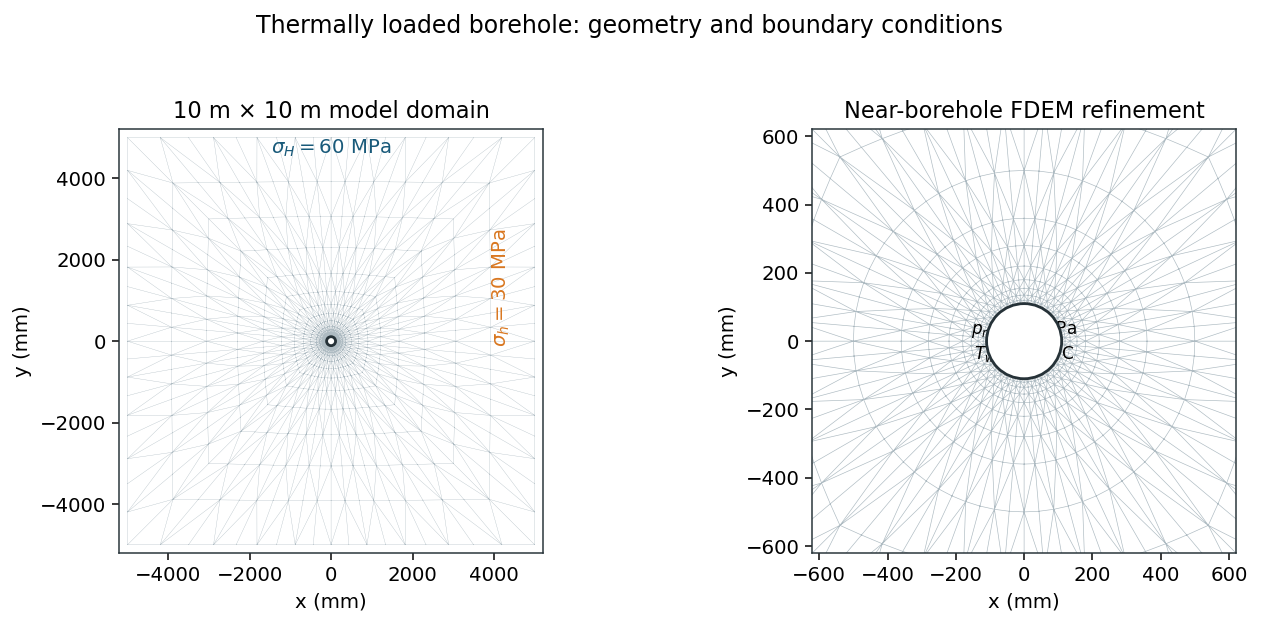

In [ ]:
from types import SimpleNamespace
mesh = build_mesh(config)
print(f"{len(mesh.triangles):,} triangles; {len(mesh.face_a):,} cohesive interfaces")
plot_model_setup(SimpleNamespace(config=config, mesh=mesh)); plt.show()

## 5. Coupled solution

The intact pre-stress state is obtained with one sparse equilibrium solve. The outer displacement is then held while twelve implicit thermal stages drive explicit, dynamically relaxed mechanical updates. The default calculation normally takes about two minutes.

In [ ]:
result = run_thermal_breakout(config)
profile = load_irazu_radial_profile(project_root / "data" / "irazu_radial_profile.csv")
stress_history = load_irazu_stress_history(project_root.parent / "data" / "Plot_3.csv")
metrics = comparison_metrics(result, profile)
display(metrics.to_frame("value"))

2304 triangles, 3384 cohesive interfaces, dt=2.979e-08 s, 11,400 mechanical steps
Final temperature = 140.00 °C; broken interfaces = 30
                                         value
temperature_profile_rmse_c            5.601158
preheat_kirsch_hoop_rmse_mpa          4.842064
top_bottom_damage_fraction            0.964793
baseline_broken_interfaces            0.000000
final_broken_interfaces              30.000000
final_monitor_stress_magnitude_mpa   82.411652
final_maximum_temperature_c         140.000000


## 6. Temperature validation against 367,002 exported Irazu points

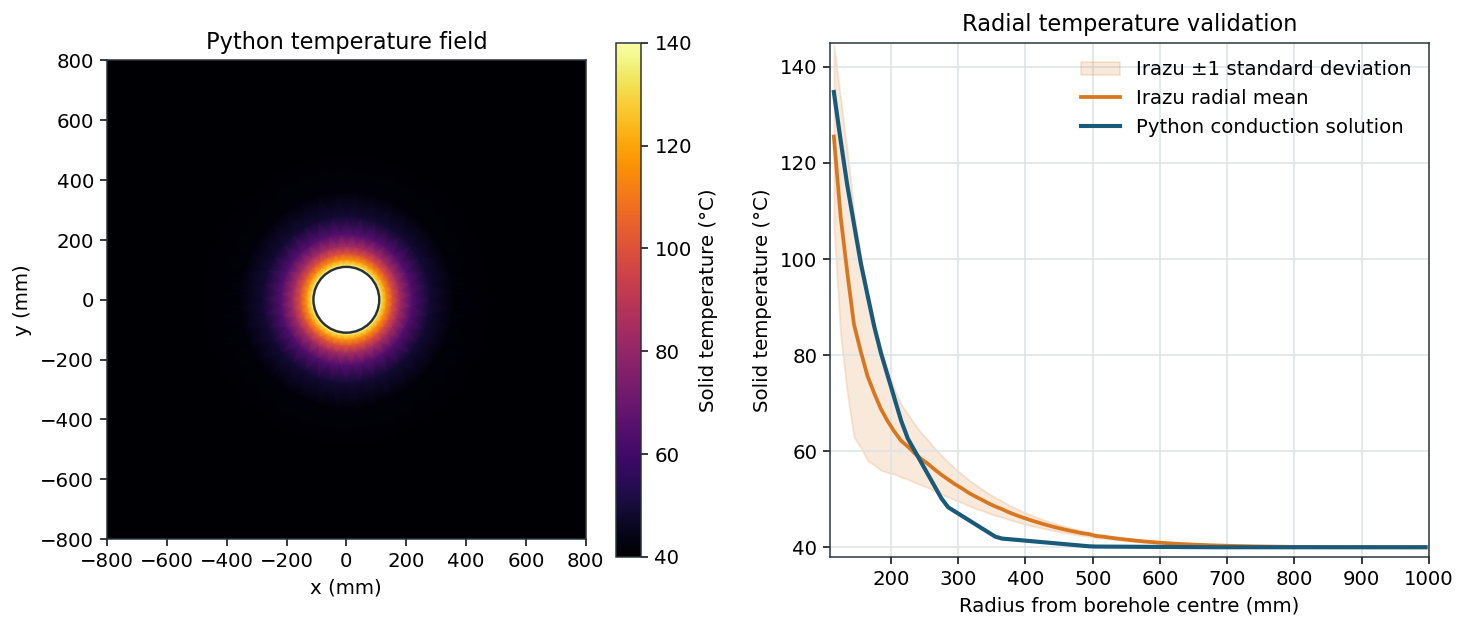

In [ ]:
plot_temperature_comparison(result, profile); plt.show()

## 7. Kirsch elastic check before thermal damage

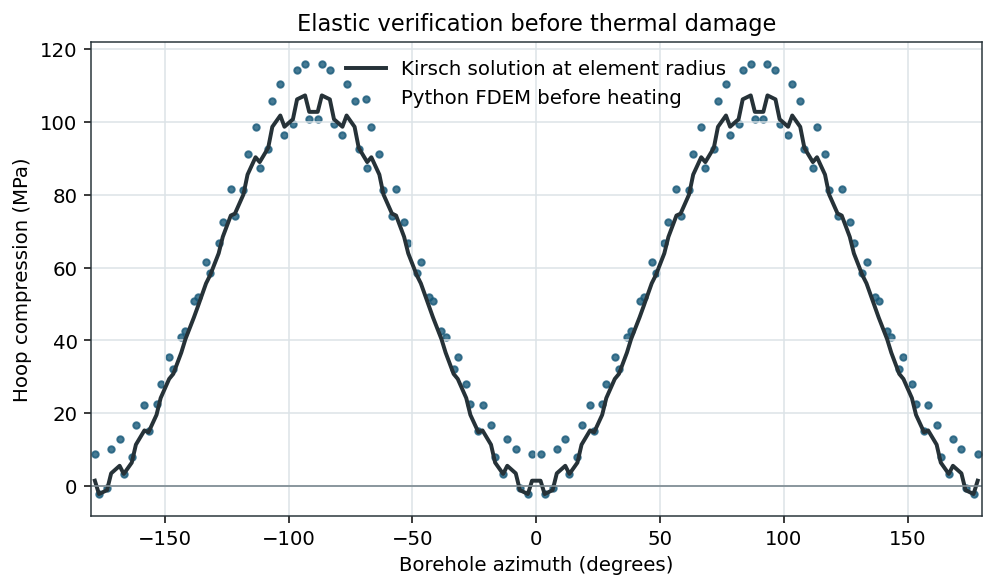

In [ ]:
plot_kirsch_validation(result); plt.show()

## 8. Cohesive localization during heating

Damage is expected to concentrate at the top and bottom of the borehole under the larger horizontal stress. Because this compact solver has no general fragment-to-fragment contact search, I interpret the final state as breakout initiation and shallow wall spalling, not a completed detached cavity.

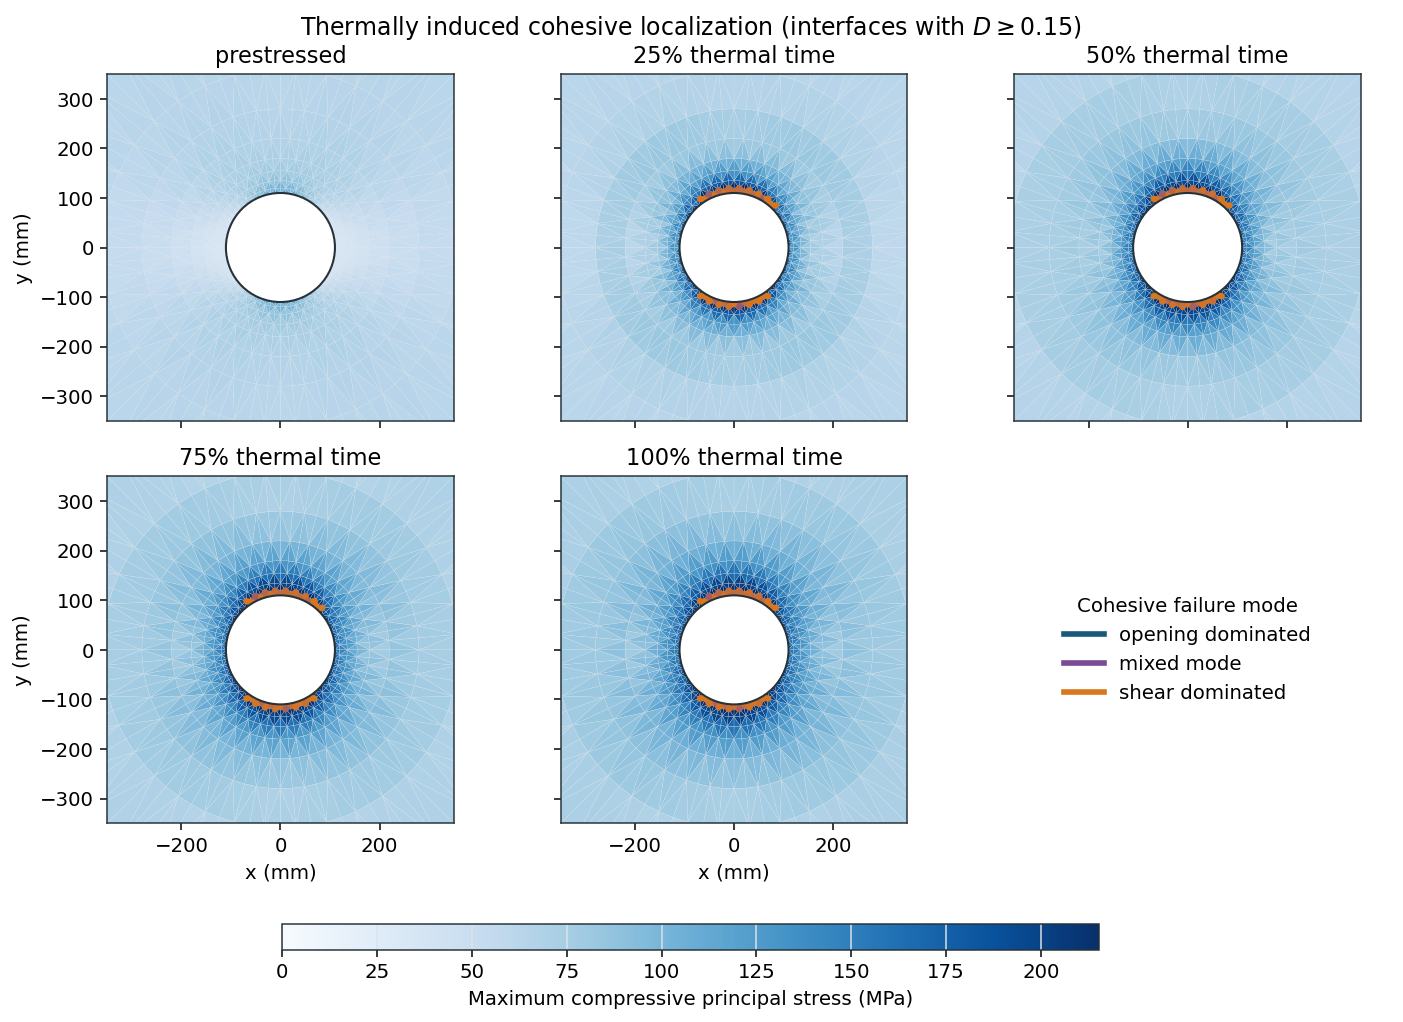

In [ ]:
plot_breakout_evolution(result); plt.show()

## 9. Damage growth and quasi-static energy diagnostic

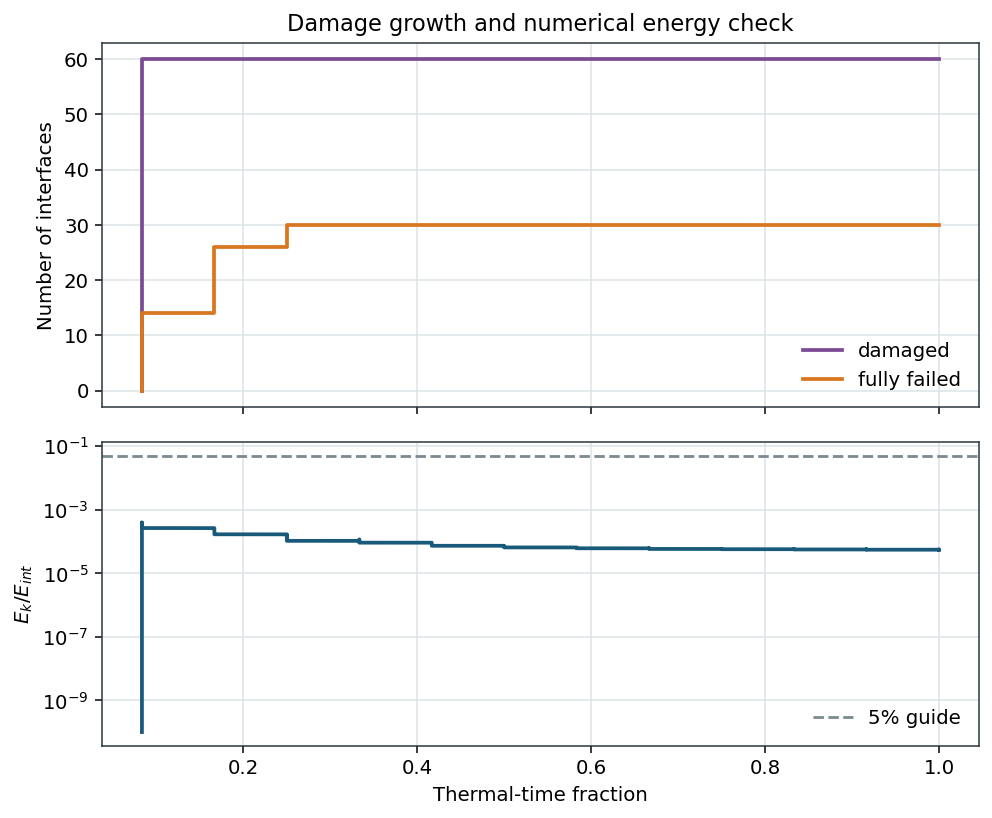

In [ ]:
plot_damage_and_energy(result); plt.show()

## 10. Stress-history comparison

The Irazu probe coordinates were not preserved, so the comparison below normalizes both trends. It is not claimed as an absolute point-to-point stress validation.

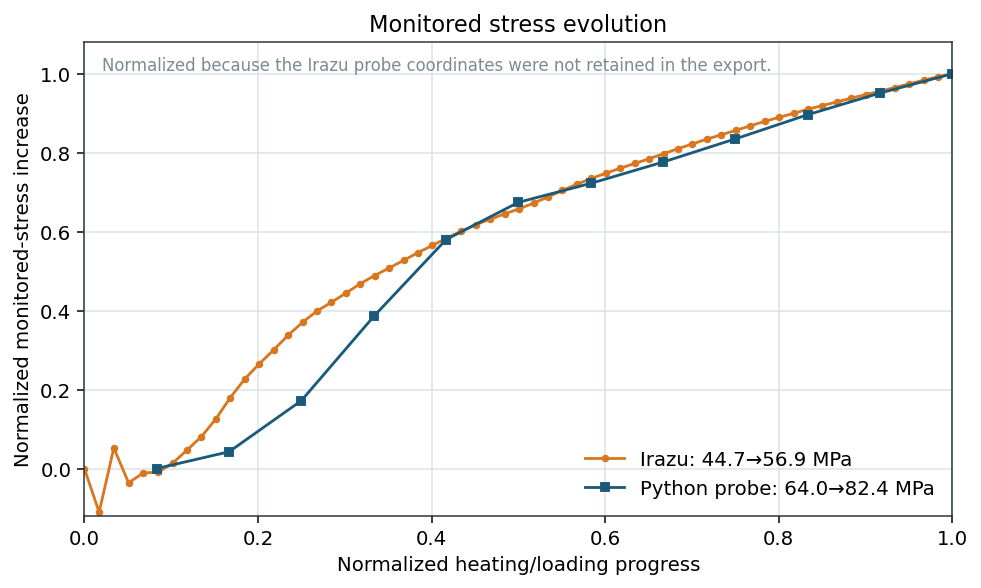

In [ ]:
plot_stress_history(result, stress_history); plt.show()

## Conclusions

The reconstruction combines heat conduction, plane-strain deformation and cohesive failure in one inspectable workflow. It recovers the radial thermal decay, the pre-heating Kirsch trend and top–bottom localization without pre-heating fracture. Its principal limitation is the absence of general detached-fragment contact; that is the logical next extension together with mesh/time-step convergence studies.